In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import timm 
from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset, Subset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/datasets/hophamsailam/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor
CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'DenseNet121'
MODEL_NAME

'DenseNet121'

In [ ]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

In [9]:
def get_data_loaders(train_dir: str = TRAIN_DIR,batch_size: int = BATCH_SIZE, train_ratio: float = TRAIN_RATIO, val_ratio: float = VAL_RATIO, test_ratio: float = TEST_RATIO) -> tuple[DataLoader, DataLoader]:
    """
    Constructs Stratified DataLoaders for Train, Validation, and Test sets (80/10/10).

    Logic:
    1. 'Two-Lens' Strategy: 
       - Train Set gets Augmented View.
       - Val & Test Sets get Clean View (Normalization only).
    2. Double Stratified Split:
       - Step 1: Split Total -> Train (80%) + Temp (20%).
       - Step 2: Split Temp -> Val (50% of Temp) + Test (50% of Temp).
         (Note: 50% of 20% = 10% of Total).

    Args:
        train_dir (str): Root directory.
        batch_size (int): Batch size.
        train_ratio, val_ratio, test_ratio: Split proportions.

    Returns:
        Tuple[DataLoader, DataLoader, DataLoader]: (train_loader, val_loader, test_loader)
    """
    # Sanity Check: Ensure ratios sum to 1.0
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-5, "Split ratios must sum to 1.0"
    
    # Standard ImageNet normalization statistics 
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Both Validation and Test sets must use the exact same clean pipeline.
    eval_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())
    
    # We create lists to hold the sub-datasets.
    # Note: images are lazy-loaded.
    train_view_subsets = [] 
    # View for both Val and Test
    eval_view_subsets = [] 
    # List to store labels for stratification
    all_labels = [] 

    # Iterate through all subsets (1 to 5) to merge them into a single pool  
    for i in range(1, 6):
        subset_path = os.path.join(train_dir, f'Subset_{i}')
        if os.path.exists(subset_path):
            # Load dataset reference
            ds_train_view = ImageFolder(root=subset_path, transform=train_transform)
            ds_eval_view = ImageFolder(root=subset_path, transform=eval_transform)
            
            train_view_subsets.append(ds_train_view)
            eval_view_subsets.append(ds_eval_view)
            
            # Extract labels for Stratification
            # ImageFolder.targets gives a list of labels for that folder
            all_labels.extend(ds_train_view.targets)
        else:
            print(f"Path not found: {subset_path}")

    # Concatenate all subsets into two massive datasets
    combined_train_view = ConcatDataset(train_view_subsets)
    combined_eval_view = ConcatDataset(eval_view_subsets)
    # We split indices based on 'all_labels' to ensure equal class distribution
    total_samples = len(combined_train_view)
    indices = list(range(total_samples))

    train_indices, temp_indices = train_test_split(indices, train_size=train_ratio, shuffle=True, random_state=SEED, stratify= all_labels)
    temp_labels = [all_labels[i] for i in temp_indices]
    # SPLIT 2: Separate Val (10%) from Test (10%)
    # Logic: Val is 10% total, Test is 10% total. Temp is 20% total.
    # So we split Temp in half (0.5).
    relative_test_size = test_ratio / (val_ratio + test_ratio) # 0.1 / 0.2 = 0.5

    val_indices, test_indices = train_test_split(temp_indices, test_size= relative_test_size, stratify= temp_labels, shuffle= True, random_state= SEED)
    
    # Mapping indices to views 
    # Train indices: Mapped to Augmented Dataset
    train_dataset = Subset(combined_train_view, train_indices)

    # Val/ test indices: mapped to clean dataset
    val_dataset = Subset(combined_eval_view, val_indices)
    test_dataset = Subset(combined_eval_view, test_indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader

In [10]:
class DenseNet121(nn.Module):
    """
    DenseNet121-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: DenseNet121 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained DenseNet121
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        backbone = models.densenet121(weights=weights)

        # DenseNet121 .features contains all Conv/Relu/MaxPool layers
        self.features = backbone.features

        # Freezing parameters to prevent updating during training
        for param in self.features.parameters():
            param.requires_grad = False

        # Define Custom Classifier Head.
        self.in_features = 1024 
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 1024, H, W) -> (Batch, 1024, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 1024, 1, 1) -> (Batch, 1024)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W).
                              Expected standard ImageNet normalization.

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """
        
        # Feature extraction (Frozen)
        x = self.features(x)
        # The torchvision.models.densenet121 `.features` block ends with a 
        # BatchNorm layer (norm5), which outputs both negative and positive values.
        # We MUST apply ReLU here to zero out negative values (noise/background).
        x = F.relu(x, inplace=True)
        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)
        
        # Output Logits
        logits = self.classifier(x)
        
        return logits

In [11]:
def build_densenet121(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> DenseNet121:
    """
    Factory function to instantiate the customized DenseNet121 model for Transfer Learning.

    This function initializes a `DenseNet121` which includes:
    1. A frozen DenseNet121 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (ReLU -> Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        DenseNet121: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """
    
    model = DenseNet121(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the DenseNet121 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_densenet121().to(device=device)

    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()

        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler (monitors validation loss)
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint (Save Best Model)
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, test_loader: DataLoader, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_densenet121().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            test_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_test += torch.sum(preds == labels)
            total_test += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = test_loss / total_test
    acc = float(correct_test) / total_test

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of DenseNet121 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of DenseNet121 Feature Indices:
    - Block 5: Unfreeze DenseBlock 4 
    - Block 4: Unfreeze DenseBlock 3 
    - Block 3: Unfreeze DenseBlock 2 
    - Block 2: Unfreeze DenseBlock 1 
    - Block 1: Unfreeze Everything (Including Stem: Conv0, Norm0...).
    Args:
        model (nn.Module): The DenseNet121 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last Dense Block (DenseBlock 4) and classifier.
            - 4: Train from DenseBlock 3 onwards.
            - 3: Train from DenseBlock 2 onwards.
            - 2: Train from DenseBlock 1 onwards (skipping Stem).
            - 1: Train the entire network.
    """

    # Map the abstract "Block Number" to the actual starting layer index in model.features
    block_indices = {
        5: 10, 
        4: 8,  
        3: 6, 
        2: 4,  
        1: 0,  
    }


    start_index = block_indices[block_num]

    # 1. Configure Backbone
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            for param in child.parameters():
                param.requires_grad = True
        else:
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head 
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the DenseNet121 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards.
    4. Trains the model with a lower learning rate to adapt features without destroying them.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        block (int): The DenseNet121 block number to unfreeze (e.g., 5, 4, 3...).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to MODEL_NAME.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_densenet121().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    
    # 3. Unfreeze specific layers
    # Use the helper function to set requires_grad=True for the target block
    set_trainable_from_block(model=model, block_num=block)

    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()

        # Disable BatchNorm
        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
        
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader,test_loader: DataLoader, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific DenseNet121 block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}.pth')

    model = build_densenet121().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    test_loss = 0.0
    correct_test = 0
    total_test = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in test_loader: # loop test loader
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_test += torch.sum(preds == labels)
            total_test += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = test_loss / total_test
    acc = float(correct_test) / total_test

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Block 6
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 209MB/s]


Epoch 1/50 | loss: 0.5193 - accuracy: 0.4406 | val_loss: 0.4020 - val_accuracy: 0.5850
val_accuracy improved from 0.0000 to 0.5850, saving weights to /kaggle/working/DenseNet121_block_6.pth


Epoch 2/50 | loss: 0.4144 - accuracy: 0.5581 | val_loss: 0.3469 - val_accuracy: 0.6503
val_accuracy improved from 0.5850 to 0.6503, saving weights to /kaggle/working/DenseNet121_block_6.pth


Epoch 3/50 | loss: 0.3480 - accuracy: 0.6287 | val_loss: 0.2967 - val_accuracy: 0.7026
val_accuracy improved from 0.6503 to 0.7026, saving weights to /kaggle/working/DenseNet121_block_6.pth


...

Epoch 30/50 | loss: 0.1590 - accuracy: 0.8242 | val_loss: 0.1495 - val_accuracy: 0.8268
val_accuracy did not improve from 0.8431


Epoch 31/50 | loss: 0.1474 - accuracy: 0.8462 | val_loss: 0.1451 - val_accuracy: 0.8301
val_accuracy did not improve from 0.8431


Epoch 32/50 | loss: 0.1510 - accuracy: 0.8339 | val_loss: 0.1411 - val_accuracy: 0.8366
val_accuracy did not improve from 0.8431


Epoch 33/50 | loss: 0.1563 - accuracy: 0.8344 | val_loss: 0.1457 - val_accuracy: 0.8301
val_accuracy did not improve from 0.8431


Epoch 34/50 | loss: 0.1571 - accuracy: 0.8303 | val_loss: 0.1421 - val_accuracy: 0.8268
val_accuracy did not improve from 0.8431
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.144242  0.843648
                  precision    recall  f1-score   support

    Glioma Tumor       0.85      0.93      0.89       143
Meningioma Tumor       0.71      0.63      0.67        71
 Pituitary Tumor       0.93      0.87      0.90        93

        accuracy                           0.84       307
       macro avg       0.83      0.81      0.82       307
    weighted avg       0.84      0.84      0.84       307



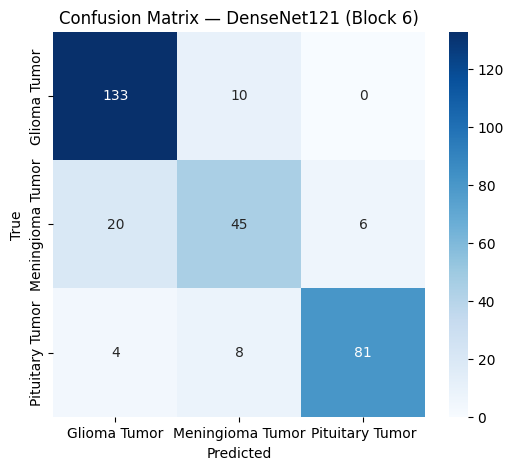

Block 5


Epoch 1/50 | loss: 0.1463 - accuracy: 0.8470 | val_loss: 0.1305 - val_accuracy: 0.8497
val_accuracy improved from 0.0000 to 0.8497, saving weights to /kaggle/working/DenseNet121_block_5.pth


Epoch 2/50 | loss: 0.1348 - accuracy: 0.8507 | val_loss: 0.1239 - val_accuracy: 0.8497
val_accuracy did not improve from 0.8497


Epoch 3/50 | loss: 0.1218 - accuracy: 0.8654 | val_loss: 0.1271 - val_accuracy: 0.8562
val_accuracy improved from 0.8497 to 0.8562, saving weights to /kaggle/working/DenseNet121_block_5.pth


Epoch 4/50 | loss: 0.1135 - accuracy: 0.8707 | val_loss: 0.1104 - val_accuracy: 0.8595
val_accuracy improved from 0.8562 to 0.8595, saving weights to /kaggle/working/DenseNet121_block_5.pth


...

Epoch 44/50 | loss: 0.0397 - accuracy: 0.9531 | val_loss: 0.0518 - val_accuracy: 0.9444
val_accuracy did not improve from 0.9477


Epoch 45/50 | loss: 0.0383 - accuracy: 0.9498 | val_loss: 0.0527 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9477


Epoch 46/50 | loss: 0.0338 - accuracy: 0.9551 | val_loss: 0.0525 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9477


Epoch 47/50 | loss: 0.0334 - accuracy: 0.9543 | val_loss: 0.0521 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9477


Epoch 48/50 | loss: 0.0360 - accuracy: 0.9531 | val_loss: 0.0519 - val_accuracy: 0.9412
val_accuracy did not improve from 0.9477
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.065959  0.934853
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.94       143
Meningioma Tumor       0.87      0.86      0.87        71
 Pituitary Tumor       0.96      0.99      0.97        93

        accuracy                           0.93       307
       macro avg       0.93      0.93      0.93       307
    weighted avg       0.93      0.93      0.93       307



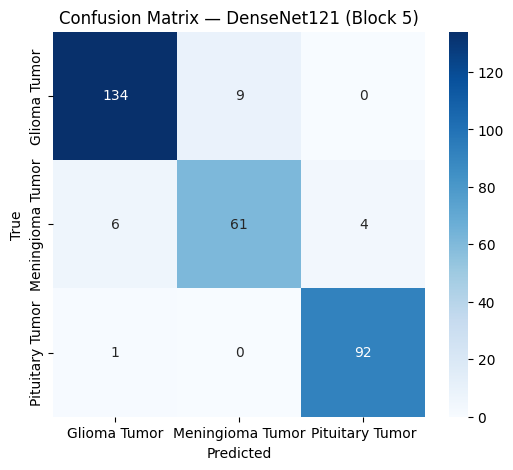

Block 4


Epoch 1/50 | loss: 0.0436 - accuracy: 0.9400 | val_loss: 0.0584 - val_accuracy: 0.9281
val_accuracy improved from 0.0000 to 0.9281, saving weights to /kaggle/working/DenseNet121_block_4.pth


Epoch 2/50 | loss: 0.0379 - accuracy: 0.9510 | val_loss: 0.0447 - val_accuracy: 0.9412
val_accuracy improved from 0.9281 to 0.9412, saving weights to /kaggle/working/DenseNet121_block_4.pth


Epoch 3/50 | loss: 0.0298 - accuracy: 0.9580 | val_loss: 0.0426 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9412


Epoch 4/50 | loss: 0.0357 - accuracy: 0.9547 | val_loss: 0.0373 - val_accuracy: 0.9575
val_accuracy improved from 0.9412 to 0.9575, saving weights to /kaggle/working/DenseNet121_block_4.pth


...

Epoch 6/50 | loss: 0.0278 - accuracy: 0.9629 | val_loss: 0.0383 - val_accuracy: 0.9542
val_accuracy did not improve from 0.9575


Epoch 7/50 | loss: 0.0273 - accuracy: 0.9665 | val_loss: 0.0397 - val_accuracy: 0.9575
val_accuracy did not improve from 0.9575


Epoch 8/50 | loss: 0.0264 - accuracy: 0.9674 | val_loss: 0.0420 - val_accuracy: 0.9510
val_accuracy did not improve from 0.9575


Epoch 9/50 | loss: 0.0191 - accuracy: 0.9759 | val_loss: 0.0333 - val_accuracy: 0.9575
val_accuracy did not improve from 0.9575


Epoch 10/50 | loss: 0.0175 - accuracy: 0.9776 | val_loss: 0.0373 - val_accuracy: 0.9575
val_accuracy did not improve from 0.9575
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.057891  0.938111
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.94      0.95       143
Meningioma Tumor       0.87      0.87      0.87        71
 Pituitary Tumor       0.96      0.99      0.97        93

        accuracy                           0.94       307
       macro avg       0.93      0.93      0.93       307
    weighted avg       0.94      0.94      0.94       307



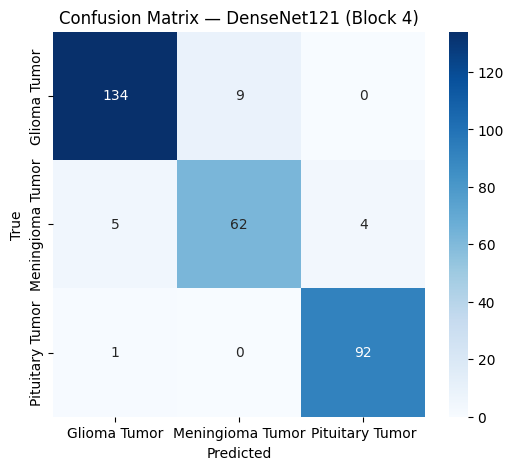

Block 3


Epoch 1/50 | loss: 0.0344 - accuracy: 0.9527 | val_loss: 0.0438 - val_accuracy: 0.9608
val_accuracy improved from 0.0000 to 0.9608, saving weights to /kaggle/working/DenseNet121_block_3.pth


Epoch 2/50 | loss: 0.0316 - accuracy: 0.9629 | val_loss: 0.0566 - val_accuracy: 0.9346
val_accuracy did not improve from 0.9608


Epoch 3/50 | loss: 0.0262 - accuracy: 0.9637 | val_loss: 0.0309 - val_accuracy: 0.9673
val_accuracy improved from 0.9608 to 0.9673, saving weights to /kaggle/working/DenseNet121_block_3.pth


Epoch 4/50 | loss: 0.0250 - accuracy: 0.9694 | val_loss: 0.0417 - val_accuracy: 0.9444
val_accuracy did not improve from 0.9673


Epoch 5/50 | loss: 0.0209 - accuracy: 0.9735 | val_loss: 0.0337 - val_accuracy: 0.9542
val_accuracy did not improve from 0.9673


Epoch 6/50 | loss: 0.0183 - accuracy: 0.9763 | val_loss: 0.0292 - val_accuracy: 0.9641
val_accuracy did not improve from 0.9673


Epoch 7/50 | loss: 0.0175 - accuracy: 0.9792 | val_loss: 0.0433 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9673


Epoch 8/50 | loss: 0.0174 - accuracy: 0.9784 | val_loss: 0.0484 - val_accuracy: 0.9510
val_accuracy did not improve from 0.9673


Epoch 9/50 | loss: 0.0171 - accuracy: 0.9763 | val_loss: 0.0401 - val_accuracy: 0.9510
val_accuracy did not improve from 0.9673
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.055738  0.934853
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.95       143
Meningioma Tumor       0.87      0.86      0.87        71
 Pituitary Tumor       0.96      0.98      0.97        93

        accuracy                           0.93       307
       macro avg       0.93      0.93      0.93       307
    weighted avg       0.93      0.93      0.93       307



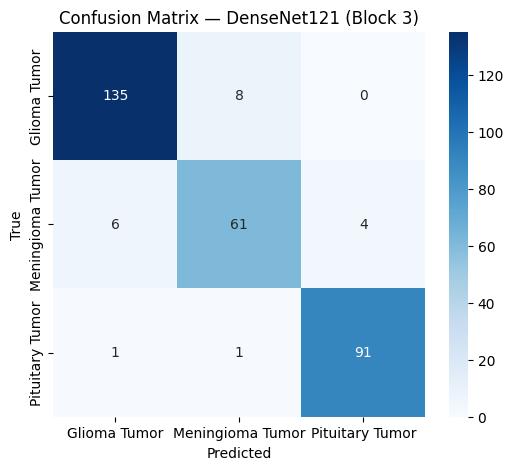

Block 2


Epoch 1/50 | loss: 0.0262 - accuracy: 0.9694 | val_loss: 0.0381 - val_accuracy: 0.9575
val_accuracy improved from 0.0000 to 0.9575, saving weights to /kaggle/working/DenseNet121_block_2.pth


Epoch 2/50 | loss: 0.0199 - accuracy: 0.9780 | val_loss: 0.0391 - val_accuracy: 0.9510
val_accuracy did not improve from 0.9575


Epoch 3/50 | loss: 0.0211 - accuracy: 0.9751 | val_loss: 0.0257 - val_accuracy: 0.9673
val_accuracy improved from 0.9575 to 0.9673, saving weights to /kaggle/working/DenseNet121_block_2.pth


Epoch 4/50 | loss: 0.0210 - accuracy: 0.9743 | val_loss: 0.0328 - val_accuracy: 0.9641
val_accuracy did not improve from 0.9673


...

Epoch 11/50 | loss: 0.0069 - accuracy: 0.9910 | val_loss: 0.0262 - val_accuracy: 0.9804
val_accuracy did not improve from 0.9804


Epoch 12/50 | loss: 0.0063 - accuracy: 0.9939 | val_loss: 0.0263 - val_accuracy: 0.9739
val_accuracy did not improve from 0.9804


Epoch 13/50 | loss: 0.0065 - accuracy: 0.9918 | val_loss: 0.0280 - val_accuracy: 0.9739
val_accuracy did not improve from 0.9804


Epoch 14/50 | loss: 0.0070 - accuracy: 0.9927 | val_loss: 0.0280 - val_accuracy: 0.9706
val_accuracy did not improve from 0.9804


Epoch 15/50 | loss: 0.0046 - accuracy: 0.9955 | val_loss: 0.0283 - val_accuracy: 0.9706
val_accuracy did not improve from 0.9804
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.053631   0.95114
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.95       143
Meningioma Tumor       0.91      0.87      0.89        71
 Pituitary Tumor       0.98      1.00      0.99        93

        accuracy                           0.95       307
       macro avg       0.95      0.94      0.95       307
    weighted avg       0.95      0.95      0.95       307



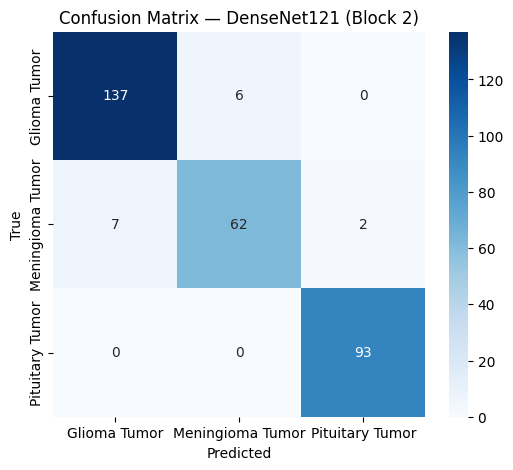

Block 1


Epoch 1/50 | loss: 0.0157 - accuracy: 0.9800 | val_loss: 0.0265 - val_accuracy: 0.9706
val_accuracy improved from 0.0000 to 0.9706, saving weights to /kaggle/working/DenseNet121_block_1.pth


Epoch 2/50 | loss: 0.0118 - accuracy: 0.9861 | val_loss: 0.0254 - val_accuracy: 0.9739
val_accuracy improved from 0.9706 to 0.9739, saving weights to /kaggle/working/DenseNet121_block_1.pth


Epoch 3/50 | loss: 0.0131 - accuracy: 0.9825 | val_loss: 0.0298 - val_accuracy: 0.9673
val_accuracy did not improve from 0.9739


Epoch 4/50 | loss: 0.0095 - accuracy: 0.9865 | val_loss: 0.0249 - val_accuracy: 0.9739
val_accuracy did not improve from 0.9739


...

Epoch 10/50 | loss: 0.0056 - accuracy: 0.9927 | val_loss: 0.0259 - val_accuracy: 0.9739
val_accuracy did not improve from 0.9837


Epoch 11/50 | loss: 0.0141 - accuracy: 0.9857 | val_loss: 0.0295 - val_accuracy: 0.9641
val_accuracy did not improve from 0.9837


Epoch 12/50 | loss: 0.0072 - accuracy: 0.9910 | val_loss: 0.0268 - val_accuracy: 0.9641
val_accuracy did not improve from 0.9837


Epoch 13/50 | loss: 0.0047 - accuracy: 0.9951 | val_loss: 0.0162 - val_accuracy: 0.9771
val_accuracy did not improve from 0.9837


Epoch 14/50 | loss: 0.0037 - accuracy: 0.9959 | val_loss: 0.0179 - val_accuracy: 0.9771
val_accuracy did not improve from 0.9837
early stopping, restoring model weights from the end of the best epoch
         Model      Loss  Accuracy
0  DenseNet121  0.051594  0.947883
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.95       143
Meningioma Tumor       0.91      0.86      0.88        71
 Pituitary Tumor       0.97      1.00      0.98        93

        accuracy                           0.95       307
       macro avg       0.94      0.94      0.94       307
    weighted avg       0.95      0.95      0.95       307



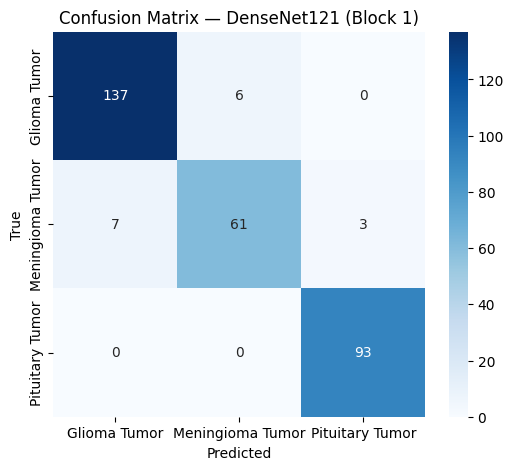

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

train_loader, val_loader, test_loader = get_data_loaders()

print(f'Block 6')
acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, test_loader= test_loader))

torch.cuda.empty_cache()
gc.collect()

for block in range(5, 0, -1):
    acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
    print(f'Block {block}')
    acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader,test_loader= test_loader, block=block))

    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 84.36%
Accuracy unfreeze block 5 - block 6: 93.49%
Accuracy unfreeze block 4 - block 6: 93.81%
Accuracy unfreeze block 3 - block 6: 93.49%
Accuracy unfreeze block 2 - block 6: 95.11%
Accuracy unfreeze block 1 - block 6: 94.79%
